# DART Pilot with Qwen2.5-7B-Instruct and QLoRA

This notebook evaluates whether the WebNLG QLoRA pipeline can be
adapted to the DART structured data-to-text dataset using a small
pilot subset.

In [12]:
from pathlib import Path

import torch
import pandas as pd
import numpy as np

from datasets import load_dataset

BASE = Path.home() / "MyWork" / "LoRA_Reproduction"
DART_DIR = BASE / "generation" / "dart"
OUTPUT_DIR = DART_DIR / "output"
RESULTS_DIR = BASE / "results" / "dart"

DART_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu130
CUDA available: True
GPU: NVIDIA L4


In [13]:
from datasets import load_dataset

data_files = {
    "train": (
        "hf://datasets/GEM/dart@refs%2Fconvert%2Fparquet/"
        "default/train/0000.parquet"
    ),
    "validation": (
        "hf://datasets/GEM/dart@refs%2Fconvert%2Fparquet/"
        "default/validation/0000.parquet"
    ),
    "test": (
        "hf://datasets/GEM/dart@refs%2Fconvert%2Fparquet/"
        "default/test/0000.parquet"
    ),
}

dart = load_dataset(
    "parquet",
    data_files=data_files,
)

print(dart)
print(dart["train"].column_names)
print(dart["train"][0])

DatasetDict({
    train: Dataset({
        features: ['gem_id', 'gem_parent_id', 'dart_id', 'tripleset', 'subtree_was_extended', 'target_sources', 'target', 'references'],
        num_rows: 62659
    })
    validation: Dataset({
        features: ['gem_id', 'gem_parent_id', 'dart_id', 'tripleset', 'subtree_was_extended', 'target_sources', 'target', 'references'],
        num_rows: 2768
    })
    test: Dataset({
        features: ['gem_id', 'gem_parent_id', 'dart_id', 'tripleset', 'subtree_was_extended', 'target_sources', 'target', 'references'],
        num_rows: 5097
    })
})
['gem_id', 'gem_parent_id', 'dart_id', 'tripleset', 'subtree_was_extended', 'target_sources', 'target', 'references']
{'gem_id': 'dart-train-0', 'gem_parent_id': 'dart-train-0', 'dart_id': 0, 'tripleset': [['First Clearing', 'LOCATION', 'On NYS 52 1 Mi. Youngsville'], ['On NYS 52 1 Mi. Youngsville', 'CITY_OR_TOWN', 'Callicoon, New York']], 'subtree_was_extended': False, 'target_sources': ['WikiTableQuestions_mt

In [14]:
SEED = 42

train_dataset = (
    dart["train"]
    .shuffle(seed=SEED)
    .select(range(300))
)

validation_dataset = (
    dart["validation"]
    .shuffle(seed=SEED)
    .select(range(60))
)

test_dataset = (
    dart["test"]
    .shuffle(seed=SEED)
    .select(range(30))
)

print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

Train: 300
Validation: 60
Test: 30


In [15]:
example = train_dataset[0]

for key, value in example.items():
    print("\nFIELD:", key)
    print("TYPE:", type(value))
    print("VALUE:", value)


FIELD: gem_id
TYPE: <class 'str'>
VALUE: dart-train-36989

FIELD: gem_parent_id
TYPE: <class 'str'>
VALUE: dart-train-36989

FIELD: dart_id
TYPE: <class 'int'>
VALUE: 20891

FIELD: tripleset
TYPE: <class 'list'>
VALUE: [['Fitzbillies', 'eatType', 'coffee shop'], ['Fitzbillies', 'food', 'Fast food'], ['Fitzbillies', 'priceRange', 'cheap'], ['Fitzbillies', 'customer rating', 'average'], ['Fitzbillies', 'area', 'city centre'], ['Fitzbillies', 'familyFriendly', 'no']]

FIELD: subtree_was_extended
TYPE: <class 'NoneType'>
VALUE: None

FIELD: target_sources
TYPE: <class 'list'>
VALUE: ['e2e', 'e2e', 'e2e', 'e2e']

FIELD: target
TYPE: <class 'str'>
VALUE: There is a cheap fast food coffee shop in the city centre, Fitzbillies. It is not family-friendly and its rating is average.

FIELD: references
TYPE: <class 'list'>
VALUE: []


In [16]:
from pprint import pprint

pprint(train_dataset[0])

{'dart_id': 20891,
 'gem_id': 'dart-train-36989',
 'gem_parent_id': 'dart-train-36989',
 'references': [],
 'subtree_was_extended': None,
 'target': 'There is a cheap fast food coffee shop in the city centre, '
           'Fitzbillies. It is not family-friendly and its rating is average.',
 'target_sources': ['e2e', 'e2e', 'e2e', 'e2e'],
 'tripleset': [['Fitzbillies', 'eatType', 'coffee shop'],
               ['Fitzbillies', 'food', 'Fast food'],
               ['Fitzbillies', 'priceRange', 'cheap'],
               ['Fitzbillies', 'customer rating', 'average'],
               ['Fitzbillies', 'area', 'city centre'],
               ['Fitzbillies', 'familyFriendly', 'no']]}


In [17]:
def format_triples(triples):
    formatted = []

    for triple in triples:
        if isinstance(triple, (list, tuple)) and len(triple) >= 3:
            subject, predicate, object_value = triple[:3]

            formatted.append(
                f"{subject} | {predicate} | {object_value}"
            )
        else:
            formatted.append(str(triple))

    return " ; ".join(formatted)


def create_prompt(example):
    triples_text = format_triples(
        example["tripleset"]
    )

    prompt = (
        "Convert the following structured triples into fluent "
        "English text.\n\n"
        f"Triples: {triples_text}\n\n"
        "Text:"
    )

    return {
        "prompt": prompt,
        "target_text": example["target"],
    }

In [11]:
formatted_example = create_prompt(
    train_dataset[0]
)

print("PROMPT:\n")
print(formatted_example["prompt"])

print("\nTARGET:\n")
print(formatted_example["target_text"])

PROMPT:

Convert the following structured triples into fluent English text.

Triples: Fitzbillies | eatType | coffee shop ; Fitzbillies | food | Fast food ; Fitzbillies | priceRange | cheap ; Fitzbillies | customer rating | average ; Fitzbillies | area | city centre ; Fitzbillies | familyFriendly | no

Text:

TARGET:

There is a cheap fast food coffee shop in the city centre, Fitzbillies. It is not family-friendly and its rating is average.


In [19]:
train_dataset = train_dataset.map(create_prompt)
validation_dataset = validation_dataset.map(create_prompt)
test_dataset = test_dataset.map(create_prompt)

print(train_dataset.column_names)

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

['gem_id', 'gem_parent_id', 'dart_id', 'tripleset', 'subtree_was_extended', 'target_sources', 'target', 'references', 'prompt', 'target_text']


In [20]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(
    "Allocated GPU memory:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

print(
    "Reserved GPU memory:",
    round(torch.cuda.memory_reserved() / 1024**3, 2),
    "GB"
)

Allocated GPU memory: 7.23 GB
Reserved GPU memory: 9.41 GB


In [21]:
import transformers
import peft
import accelerate
import bitsandbytes

print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("Accelerate:", accelerate.__version__)
print("BitsAndBytes:", bitsandbytes.__version__)

Transformers: 5.14.1
PEFT: 0.19.1
Accelerate: 1.14.0
BitsAndBytes: 0.49.2


In [22]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )
    print(
        "Reserved:",
        round(torch.cuda.memory_reserved() / 1024**3, 2),
        "GB"
    )

CUDA available: True
GPU: NVIDIA L4
Allocated: 7.23 GB
Reserved: 9.41 GB


In [23]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.bfloat16,
)

model.config.use_cache = False

print("Model loaded successfully")
print("Model device:", model.device)
print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model loaded successfully
Model device: cuda:0
Pad token: <|endoftext|>
EOS token: <|im_end|>


In [24]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)

model = get_peft_model(
    model,
    lora_config,
)

model.print_trainable_parameters()

trainable params: 5,046,272 || all params: 7,620,662,784 || trainable%: 0.0662


In [25]:
MAX_LENGTH = 512

def tokenize_example(example):
    full_text = (
        example["prompt"]
        + " "
        + example["target_text"]
        + tokenizer.eos_token
    )

    tokenized = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

    tokenized["labels"] = tokenized["input_ids"].copy()

    return tokenized

In [26]:
tokenized_train = train_dataset.map(
    tokenize_example,
    remove_columns=train_dataset.column_names,
)

tokenized_validation = validation_dataset.map(
    tokenize_example,
    remove_columns=validation_dataset.column_names,
)

print(tokenized_train)
print(tokenized_validation)
print(tokenized_train[0].keys())
print(
    "First example length:",
    len(tokenized_train[0]["input_ids"])
)

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 300
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 60
})
dict_keys(['input_ids', 'attention_mask', 'labels'])
First example length: 99


In [27]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

In [28]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./dart_output",

    num_train_epochs=1,

    learning_rate=2e-4,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=8,

    eval_strategy="steps",
    eval_steps=20,

    save_strategy="steps",
    save_steps=20,

    logging_steps=5,

    save_total_limit=1,

    bf16=True,

    gradient_checkpointing=True,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none",

    remove_unused_columns=False,
)

In [29]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
)

print("Trainer ready")

Trainer ready


In [30]:
batch = data_collator([tokenized_train[0]])

batch = {
    key: value.to(model.device)
    for key, value in batch.items()
}

with torch.no_grad():
    outputs = model(**batch)

print(outputs.loss)

tensor(1.5985, device='cuda:0')


In [31]:
train_result = trainer.train()

print(train_result)

Step,Training Loss,Validation Loss
20,0.902032,0.933824
38,0.728522,0.768738


TrainOutput(global_step=38, training_loss=1.07067398648513, metrics={'train_runtime': 158.0174, 'train_samples_per_second': 1.899, 'train_steps_per_second': 0.24, 'total_flos': 1033584900139008.0, 'train_loss': 1.07067398648513, 'epoch': 1.0})


In [32]:
evaluation_results = trainer.evaluate()

print(evaluation_results)

Training Loss,Validation Loss,Step
0.728522,0.768738,38


{'eval_loss': 0.7687379717826843}


In [33]:
evaluation_results["eval_loss"]

0.7687379717826843

In [34]:
import pandas as pd

history_df = pd.DataFrame(
    trainer.state.log_history
)

display(history_df)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.014287,1.063008,0.000179,0.133333,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.386402,0.959776,0.000153,0.266667,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.129918,1.525652,0.000126,0.400000,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.902032,0.988359,0.000100,0.533333,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,0.533333,20,0.933824,10.0561,5.967,5.967,NaN,NaN,NaN,NaN,NaN
5,0.854912,1.178558,0.000074,0.666667,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.676555,0.670211,0.000047,0.800000,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.728522,0.808015,0.000021,0.933333,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,1.000000,38,0.768738,9.9866,6.008,6.008,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,1.000000,38,NaN,NaN,NaN,NaN,158.0174,1.899,0.24,1.033585e+15,1.070674


In [35]:
def generate_text(prompt, max_new_tokens=120):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=400,
    ).to(model.device)

    model.eval()

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True,
    )

    if generated_text.startswith(prompt):
        generated_text = generated_text[
            len(prompt):
        ].strip()

    return generated_text

In [36]:
generated_examples = []

for index in range(3):
    example = test_dataset[index]

    prediction = generate_text(
        example["prompt"]
    )

    generated_examples.append({
        "index": index,
        "reference": example["target_text"],
        "prediction": prediction,
    })

    print("=" * 80)
    print("TRIPLES:")
    print(example["tripleset"])

    print("\nREFERENCE:")
    print(example["target_text"])

    print("\nPREDICTION:")
    print(prediction)

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


TRIPLES:
[['The Phoenix', 'eatType', 'coffee shop'], ['The Phoenix', 'food', 'French'], ['The Phoenix', 'area', 'city centre'], ['The Phoenix', 'familyFriendly', 'yes'], ['The Phoenix', 'near', 'Crowne Plaza Hotel']]

REFERENCE:
There is a French Café The Phoenix located in the city centre near Crowne Plaza Hotel and is children friendly.

PREDICTION:
The Phoenix is a family friendly coffee shop in the city centre. It serves French food and is located near the Crowne Plaza Hotel.
TRIPLES:
[['Olympique Lyonnais', 'OWNER', 'Jean-Michel Aulas']]

REFERENCE:
Jean-Michel Aulas is the owner of Olympique Lyonnais.

PREDICTION:
Jean-Michel Aulas is the owner of Olympique Lyonnais.
TRIPLES:
[['FC Terek Grozny', 'GROUND', 'Grozny'], ['Aleksandr Prudnikov', 'YOUTH_CLUB', 'FC Spartak Moscow'], ['Aleksandr Prudnikov', 'CLUB', 'FC Terek Grozny'], ['FC Terek Grozny', 'MANAGER', 'Rashid Rakhimov'], ['Aleksandr Prudnikov', 'CLUB', 'FC Dynamo Moscow']]

REFERENCE:
Aleksandr Prudnikov played for FC Spart

In [37]:
from pathlib import Path
import json

RESULTS_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "results"
    / "dart"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

history_path = (
    RESULTS_DIR
    / "dart_pilot_history.csv"
)

history_df.to_csv(
    history_path,
    index=False,
)

dart_results = {
    "task": "DART",
    "experiment_type": "pilot",
    "model": MODEL_NAME,
    "method": "QLoRA",
    "quantization": "4-bit NF4",
    "train_examples": len(train_dataset),
    "validation_examples": len(validation_dataset),
    "test_examples": len(test_dataset),
    "epochs": 1,
    "learning_rate": 2e-4,
    "initial_forward_loss": 1.5985,
    "evaluation_results": {
        key: float(value)
        for key, value in evaluation_results.items()
        if isinstance(value, (int, float))
    },
    "generated_examples": generated_examples,
}

results_path = (
    RESULTS_DIR
    / "dart_pilot_results.json"
)

with results_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        dart_results,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("History saved to:", history_path)
print("Results saved to:", results_path)

History saved to: /home/shahd.baloum/MyWork/LoRA_Reproduction/results/dart/dart_pilot_history.csv
Results saved to: /home/shahd.baloum/MyWork/LoRA_Reproduction/results/dart/dart_pilot_results.json


In [38]:
train_result = trainer.train()

Step,Training Loss,Validation Loss
20,0.604734,0.704555
38,0.625467,0.698254


In [39]:
final_evaluation_results = trainer.evaluate()

print(final_evaluation_results)

Training Loss,Validation Loss,Step
0.625467,0.698254,38


{'eval_loss': 0.698254406452179}


In [40]:
import pandas as pd

final_history_df = pd.DataFrame(
    trainer.state.log_history
)

display(final_history_df)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.694859,0.794402,0.000179,0.133333,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.628597,0.932468,0.000153,0.266667,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.666413,1.035435,0.000126,0.400000,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.604734,0.711149,0.000100,0.533333,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,0.533333,20,0.704555,9.9775,6.014,6.014,NaN,NaN,NaN,NaN,NaN
5,0.643695,0.985985,0.000074,0.666667,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.553955,0.528925,0.000047,0.800000,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.625467,0.665534,0.000021,0.933333,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,1.000000,38,0.698254,21.2543,2.823,2.823,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,1.000000,38,NaN,NaN,NaN,NaN,197.7343,1.517,0.192,1.033585e+15,0.628002


In [41]:
generated_examples = []

for index in range(3):
    example = test_dataset[index]

    prediction = generate_text(
        example["prompt"]
    )

    generated_examples.append({
        "index": index,
        "triples": example["tripleset"],
        "reference": example["target_text"],
        "prediction": prediction,
    })

    print("=" * 80)
    print("TRIPLES:")
    print(example["tripleset"])

    print("\nREFERENCE:")
    print(example["target_text"])

    print("\nPREDICTION:")
    print(prediction)

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


TRIPLES:
[['The Phoenix', 'eatType', 'coffee shop'], ['The Phoenix', 'food', 'French'], ['The Phoenix', 'area', 'city centre'], ['The Phoenix', 'familyFriendly', 'yes'], ['The Phoenix', 'near', 'Crowne Plaza Hotel']]

REFERENCE:
There is a French Café The Phoenix located in the city centre near Crowne Plaza Hotel and is children friendly.

PREDICTION:
The Phoenix is a family friendly coffee shop in the city centre. It serves French food and is located near the Crowne Plaza Hotel.
TRIPLES:
[['Olympique Lyonnais', 'OWNER', 'Jean-Michel Aulas']]

REFERENCE:
Jean-Michel Aulas is the owner of Olympique Lyonnais.

PREDICTION:
Jean-Michel Aulas is the owner of Olympique Lyonnais.
TRIPLES:
[['FC Terek Grozny', 'GROUND', 'Grozny'], ['Aleksandr Prudnikov', 'YOUTH_CLUB', 'FC Spartak Moscow'], ['Aleksandr Prudnikov', 'CLUB', 'FC Terek Grozny'], ['FC Terek Grozny', 'MANAGER', 'Rashid Rakhimov'], ['Aleksandr Prudnikov', 'CLUB', 'FC Dynamo Moscow']]

REFERENCE:
Aleksandr Prudnikov played for FC Spart

In [42]:
from pathlib import Path
import json

RESULTS_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "results"
    / "dart"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

history_path = (
    RESULTS_DIR
    / "dart_pilot_history.csv"
)

final_history_df.to_csv(
    history_path,
    index=False,
)

dart_results = {
    "task": "DART",
    "experiment_type": "pilot",
    "model": MODEL_NAME,
    "method": "QLoRA",
    "quantization": "4-bit NF4",

    "train_examples": len(train_dataset),
    "validation_examples": len(validation_dataset),
    "test_examples": len(test_dataset),

    "training_note": (
        "Two consecutive one-epoch training runs were performed "
        "on the same 300-example subset."
    ),
    "effective_epochs": 2,

    "learning_rate": 2e-4,
    "initial_forward_loss": 1.5985,

    "final_evaluation_results": {
        key: float(value)
        for key, value in final_evaluation_results.items()
        if isinstance(value, (int, float))
    },

    "generated_examples": generated_examples,
}

results_path = (
    RESULTS_DIR
    / "dart_pilot_results.json"
)

with results_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        dart_results,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("History saved to:", history_path)
print("Results saved to:", results_path)
print(
    "Final validation loss:",
    final_evaluation_results["eval_loss"]
)

History saved to: /home/shahd.baloum/MyWork/LoRA_Reproduction/results/dart/dart_pilot_history.csv
Results saved to: /home/shahd.baloum/MyWork/LoRA_Reproduction/results/dart/dart_pilot_results.json
Final validation loss: 0.698254406452179


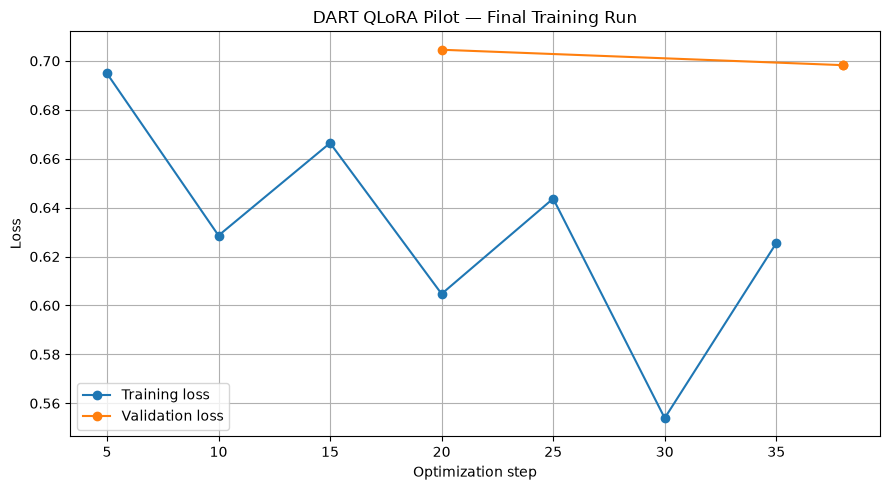

Plot saved to: /home/shahd.baloum/MyWork/LoRA_Reproduction/results/dart/dart_pilot_loss_curve.png


In [43]:
import matplotlib.pyplot as plt

training_logs = final_history_df[
    final_history_df["loss"].notna()
].copy()

evaluation_logs = final_history_df[
    final_history_df["eval_loss"].notna()
].copy()

plt.figure(figsize=(9, 5))

if not training_logs.empty:
    plt.plot(
        training_logs["step"],
        training_logs["loss"],
        marker="o",
        label="Training loss",
    )

if not evaluation_logs.empty:
    plt.plot(
        evaluation_logs["step"],
        evaluation_logs["eval_loss"],
        marker="o",
        label="Validation loss",
    )

plt.xlabel("Optimization step")
plt.ylabel("Loss")
plt.title("DART QLoRA Pilot — Final Training Run")
plt.grid(True)
plt.legend()
plt.tight_layout()

plot_path = (
    RESULTS_DIR
    / "dart_pilot_loss_curve.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Plot saved to:", plot_path)

## DART Pilot Results and Analysis

A small DART pilot was conducted using Qwen2.5-7B-Instruct with
4-bit NF4 quantization and QLoRA.

The pilot used:

- 300 training examples
- 60 validation examples
- 30 test examples
- Two consecutive one-epoch training runs

The initial forward-pass loss before training was **1.5985**.

During the final training run, validation loss decreased from
**0.7046** at step 20 to **0.6983** at step 38.

The generated outputs were generally fluent and covered most or all
of the structured facts. One simple example reproduced the reference
meaning exactly. More complex examples preserved the main facts but
occasionally simplified semantic distinctions, such as representing
a youth-club relation as a general club relation.

This is a pilot experiment rather than a complete DART benchmark
reproduction. The experiment demonstrates that the QLoRA pipeline
developed for WebNLG can also be applied successfully to another
structured data-to-text dataset.